# Temas Tratados en el Trabajo Práctico 4

* Representación del Conocimiento y Razonamiento Lógico.

* Estrategias de resolución de hipótesis: Encadenamiento hacia Adelante, Encadenamiento hacia Atrás y Resolución por Contradicción.

* Representación basada en circuitos.

## Ejercicios Teóricos

1. ¿Qué es una inferencia?

2. ¿Cómo se verifica que un modelo se infiere de la base de conocimientos?

3. Observe la siguiente base de conocimiento:

$R1: b ∧ c → a$

$R2: d ∧ e → b$

$R3: g ∧ e → b$

$R4: e → c$

$R5: d$

$R6: e$

$R7: a ∧ g → f$

        3.1 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia adelante? Este método solamente usa reglas ya incorporadas a la base de conocimiento para inferir la hipótesis, ¿qué propiedad debe tener el algoritmo para asegurar que esta inferencia sea posible?

        3.2 ¿Cómo se puede probar que $a = True$ a través del encadenamiento hacia atrás? Este método asigna un valor de verdad a la hipótesis y deriva las sentencias de la base de conocimiento, ¿qué propiedad debe tener el algoritmo para asegurar que esta derivación sea posible?

        3.3 Exprese la base de conocimiento en su Forma Normal Conjuntiva. A continuación, demuestre por contradicción que $a = True$.

4. Diseñe con lógica proposicional basada en circuitos las proposiciones *OrientadoDerecha* y *Agente ubicado en la casilla [1,2]* para el mundo de wumpus de 4x4. Dibuje el circuito correspondiente.


5. El nonograma es un juego en el cual se posee un tablero en blanco y cada fila y columna presenta información sobre la longitud de un bloque en dicha fila/columna. Además, la leyenda puede indicar más de un número, indicando esto que existen varios bloques de las longitudes mostradas por la leyenda y en el mismo orden, separados por al menos un espacio vacío.

Resuelva el nonograma de la imagen de abajo escribiendo en primer lugar cada regla que puede incorporarse a la base de conocimientos inicial e incorporando cada inferencia que realice.

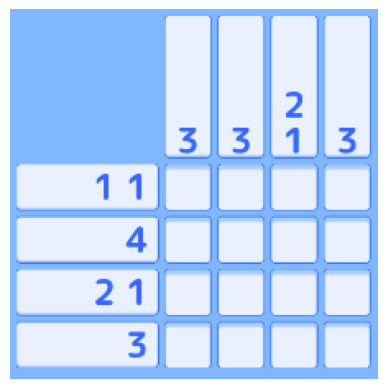

In [1]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# URL directa de Google Drive
url = "https://drive.google.com/uc?export=view&id=1SKiXvrI_TX-U4sbw60TYSRmaNYyFixmI"

# Descargar la imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen
plt.imshow(img)
plt.axis('off')  # Ocultar ejes
plt.show()

## Ejercicios de Implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

6. Implementar un motor de inferencia con encadenamiento hacia adelante. Pruébelo con las proposiciones del ejercicio 3.

7. Implementar un motor de inferencia con encadenamiento hacia atrás. Pruébelo con las proposiciones del ejercicio 3.

In [2]:
def encadenamiento_hacia_atras(meta, hechos, reglas, nivel=0, visitados=None):
    """
    Evalúa si una proposición (meta) es demostrable utilizando encadenamiento hacia atrás.
    """
    # Inicializamos el conjunto de visitados en la primera llamada para detectar ciclos
    if visitados is None:
        visitados = set()

    # Formateo visual para la traza (indentación basada en la profundidad de la recursión)
    indent = "  " * nivel
    print(f"\n{indent}Objetivo: {meta}")

    # CONDICIÓN BASE 1: La meta ya es un hecho conocido
    if meta in hechos:
        print(f"{indent}  {meta} = hecho")
        return True

    # CONDICIÓN BASE 2: Detección de ciclos lógicos
    if meta in visitados:
        print(f"{indent}  {meta} = ciclo detectado (rama abortada)")
        return False

    # Marcamos la meta actual como "en proceso de evaluación" para esta rama
    visitados.add(meta)

    # PASO RECURSIVO: Buscar reglas que puedan demostrar la meta
    if meta in reglas:
        # Iteramos sobre todas las reglas que tienen esta meta como conclusión
        for premisas in reglas[meta]:
            str_premisas = " ^ ".join(premisas)
            print(f"{indent}  {meta}")
            print(f"{indent}  <- {str_premisas}")

            todas_demostradas = True
            
            # Evaluamos cada premisa de la regla actual
            for premisa in premisas:
                # Llamada recursiva. Pasamos una COPIA de visitados para no afectar otras ramas
                resultado = encadenamiento_hacia_atras(premisa, hechos, reglas, nivel + 2, visitados.copy())
                
                if not resultado:
                    todas_demostradas = False
                    break # Falla esta regla completa, dejamos de evaluar el resto de sus premisas

            # Si todas las premisas de esta regla se demostraron, la meta queda demostrada
            if todas_demostradas:
                return True

    # Si terminamos de revisar todas las reglas y ninguna funcionó, la meta no es demostrable
    print(f"{indent}  {meta} = ?")
    return False

# ==========================================
# BASE DE CONOCIMIENTO (Ejercicio 3)
# ==========================================
hechos_ej3 = {"d", "e"} # R5 y R6

reglas_ej3 = {
    "a": [["b", "c"]],      # R1
    "b": [["d", "e"],       # R2
          ["g", "e"]],      # R3
    "c": [["e"]],           # R4
    "f": [["a", "g"]]       # R7
}

# ==========================================
# PRUEBAS Y EJECUCIÓN
# ==========================================
if __name__ == "__main__":
    print("--- DEMOSTRACIÓN DEL OBJETIVO 'a' ---")
    resultado_a = encadenamiento_hacia_atras("a", hechos_ej3, reglas_ej3)
    print(f"\nResultado final para 'a': {'DEMOSTRADA' if resultado_a else 'NO DEMOSTRABLE'}\n")

    print("-" * 50)

    print("\n--- DEMOSTRACIÓN DEL OBJETIVO 'f' (Caso de fallo) ---")
    resultado_f = encadenamiento_hacia_atras("f", hechos_ej3, reglas_ej3)
    print(f"\nResultado final para 'f': {'DEMOSTRADA' if resultado_f else 'NO DEMOSTRABLE'}\n")

--- DEMOSTRACIÓN DEL OBJETIVO 'a' ---

Objetivo: a
  a
  <- b ^ c

    Objetivo: b
      b
      <- d ^ e

        Objetivo: d
          d = hecho

        Objetivo: e
          e = hecho

    Objetivo: c
      c
      <- e

        Objetivo: e
          e = hecho

Resultado final para 'a': DEMOSTRADA

--------------------------------------------------

--- DEMOSTRACIÓN DEL OBJETIVO 'f' (Caso de fallo) ---

Objetivo: f
  f
  <- a ^ g

    Objetivo: a
      a
      <- b ^ c

        Objetivo: b
          b
          <- d ^ e

            Objetivo: d
              d = hecho

            Objetivo: e
              e = hecho

        Objetivo: c
          c
          <- e

            Objetivo: e
              e = hecho

    Objetivo: g
      g = ?
  f = ?

Resultado final para 'f': NO DEMOSTRABLE



8. Implementar un motor de inferencia por contradicción que detecte si el conjunto de proposiciones del ejercicio 3 es inconsistente.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)